In [6]:
import os
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
tqdm.pandas()
DIR = Path('~/Desktop/Texas/2022-05-12-php-test-suite-sqli-v1-0-0')

In [7]:
df = pd.read_json(DIR / "sarifs.json")

In [8]:
new_df = pd.concat([df, pd.json_normalize(df['testCases'])], axis=1).drop('testCases', axis=1)
new_df = pd.concat([new_df, pd.json_normalize(new_df['sarif.runs'].apply(lambda x: x[0]))], axis=1).drop('sarif.runs', axis=1)
new_df = pd.concat([new_df, pd.json_normalize(new_df['artifacts'].apply(lambda x: x[0]))], axis=1).drop('artifacts', axis=1)
new_df = pd.concat([new_df, pd.json_normalize(new_df['taxonomies'].apply(lambda x: x[0]))], axis=1).drop('taxonomies', axis=1)
new_df = pd.concat([new_df, pd.json_normalize(new_df['results'].apply(lambda x: x[0]))], axis=1).drop('results', axis=1)
new_df = pd.concat([new_df, pd.json_normalize(new_df['taxa'].apply(lambda x: x[0]))], axis=1).drop('taxa', axis=1)
new_df = pd.concat([new_df, pd.json_normalize(new_df['locations'].apply(lambda x: x[0]))], axis=1).drop('locations', axis=1)

new_df['vulnerability'] = ["SQL Injection" if "SQL Injection" in message else "XSS" if "Cross-site Scripting" in message else "Other" for message in new_df['message.text']]
new_df['is_sanitized'] = [state == "good" for state in new_df['properties.state']]
# new_df.to_csv('sarifs.csv', index=False)

<Axes: xlabel='vulnerability'>

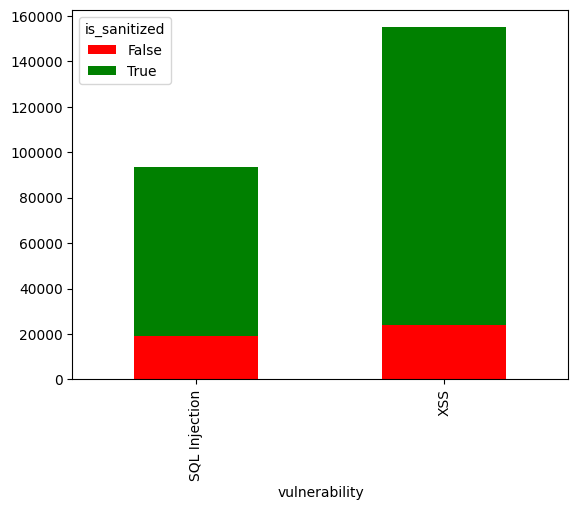

In [9]:
new_df.groupby(['vulnerability', 'is_sanitized']).size().unstack().plot(kind='bar', stacked=True, color=['red', 'green'])

In [5]:
OUT_DIR = DIR / "../php_test_suite"

def migrate(row):
    code = open(DIR / row['location.uri'])
    sanitization_status = "sanitized" if row['is_sanitized'] else "unsanitized"
    output_path = OUT_DIR / row['vulnerability'] / sanitization_status
    os.makedirs(output_path, exist_ok=True)
    with open(output_path / f"{row['properties.id']}.php", 'w') as f:
        f.write(code.read())
    code.close()

In [6]:
# new_df.progress_apply(migrate, axis=1)